# 🛍️ Customer Segmentation Using RFM Analysis
### E-Commerce Behavioral Analytics | UCI Online Retail Dataset

**Objective:** Segment customers based on purchasing behavior to identify 
high-value customers, at-risk churners, and growth opportunities.

**Tools:** Python · pandas · matplotlib · seaborn · plotly

**Dataset:** UCI Online Retail Dataset — 541,909 transactions from a UK-based 
online retailer (2010–2011)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
# Load dataset
df = pd.read_excel('C:\\Project\\customer-segmentation-rfm\\data\\Online Retail.xlsx', engine='openpyxl')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


## 1. Exploratory Data Analysis (EDA)

Before cleaning, let's understand what we're working with.

In [3]:
print("=== BASIC INFO ===")
print(f"Total rows     : {df.shape[0]:,}")
print(f"Total columns  : {df.shape[1]}")
print(f"Date range     : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products : {df['StockCode'].nunique():,}")
print(f"Countries       : {df['Country'].nunique()}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== BASIC INFO ===
Total rows     : 541,909
Total columns  : 8
Date range     : 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique customers: 4,372
Unique products : 4,070
Countries       : 38

=== MISSING VALUES ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== DATA TYPES ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


## 2. Data Cleaning

Issues to address:
- Remove rows with missing `CustomerID` (can't do RFM without it)
- Remove cancelled orders (InvoiceNo starting with 'C')
- Remove rows where Quantity or UnitPrice ≤ 0
- Keep only United Kingdom for focused analysis

In [4]:
df_clean = df.copy()

# Drop missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancellations
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative/zero quantity and price
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Focus on UK customers
df_clean = df_clean[df_clean['Country'] == 'United Kingdom']

# Create TotalPrice column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Ensure correct date type
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Rows before cleaning : {df.shape[0]:,}")
print(f"Rows after cleaning  : {df_clean.shape[0]:,}")
print(f"Rows removed         : {df.shape[0] - df_clean.shape[0]:,}")
print(f"\nCustomers remaining  : {df_clean['CustomerID'].nunique():,}")

Rows before cleaning : 541,909
Rows after cleaning  : 354,321
Rows removed         : 187,588

Customers remaining  : 3,920


## 3. RFM Calculation

- **Recency (R):** How recently did the customer make a purchase?
- **Frequency (F):** How often do they purchase?
- **Monetary (M):** How much total revenue do they generate?

In [5]:
# Snapshot date = 1 day after last transaction
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Calculate RFM
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"\nRFM Table Shape: {rfm.shape}")
rfm.describe()

Snapshot date: 2011-12-10

RFM Table Shape: (3920, 4)


,CustomerID,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00,3920.00
mean,15562.06,92.21,4.25,1864.39
std,1576.59,99.53,7.20,7482.82
min,12346.00,1.00,1.00,3.75
25%,14208.75,18.00,1.00,300.28
50%,15569.50,51.00,2.00,652.28
75%,16913.25,143.00,5.00,1576.59
max,18287.00,374.00,209.00,259657.30


In [6]:
# Score each metric 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

# Combine into RFM Score string
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

# Total RFM Score (numeric)
rfm['RFM_Total'] = (rfm['R_Score'].astype(int) + 
                    rfm['F_Score'].astype(int) + 
                    rfm['M_Score'].astype(int))

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.00,326,1,77183.60,1,1,5,115,7
1,12747.00,2,11,4196.01,5,5,5,555,15
2,12748.00,1,209,33719.73,5,5,5,555,15
3,12749.00,4,5,4090.88,5,4,5,545,14
4,12820.00,3,4,942.34,5,4,4,544,13
5,12821.00,214,1,92.72,1,1,1,111,3
6,12822.00,71,2,948.88,3,2,4,324,9
7,12823.00,75,5,1759.50,2,4,4,244,10
8,12824.00,60,1,397.12,3,1,2,312,6
9,12826.00,3,7,1474.72,5,5,4,554,14


In [7]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Can\'t Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost / Inactive'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Segment summary
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(2).sort_values('Total_Revenue', ascending=False)

print(segment_summary)

                     Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                         
Champions                       874        12.74          10.91       5305.01   
Loyal Customers                 881        33.28           3.70       1433.08   
At Risk                         415       112.71           3.66       1247.07   
Needs Attention                 408       135.46           1.95        685.55   
Can't Lose Them                 207       185.32           1.28       1215.69   
Lost / Inactive                 761       224.09           1.05        223.34   
Recent Customers                285        18.74           1.24        386.82   
Potential Loyalists              89        53.03           1.44        900.81   

                     Total_Revenue  
Segment                             
Champions               4636582.79  
Loyal Customers         1262544.09  
At Risk                  517535.13  
Need

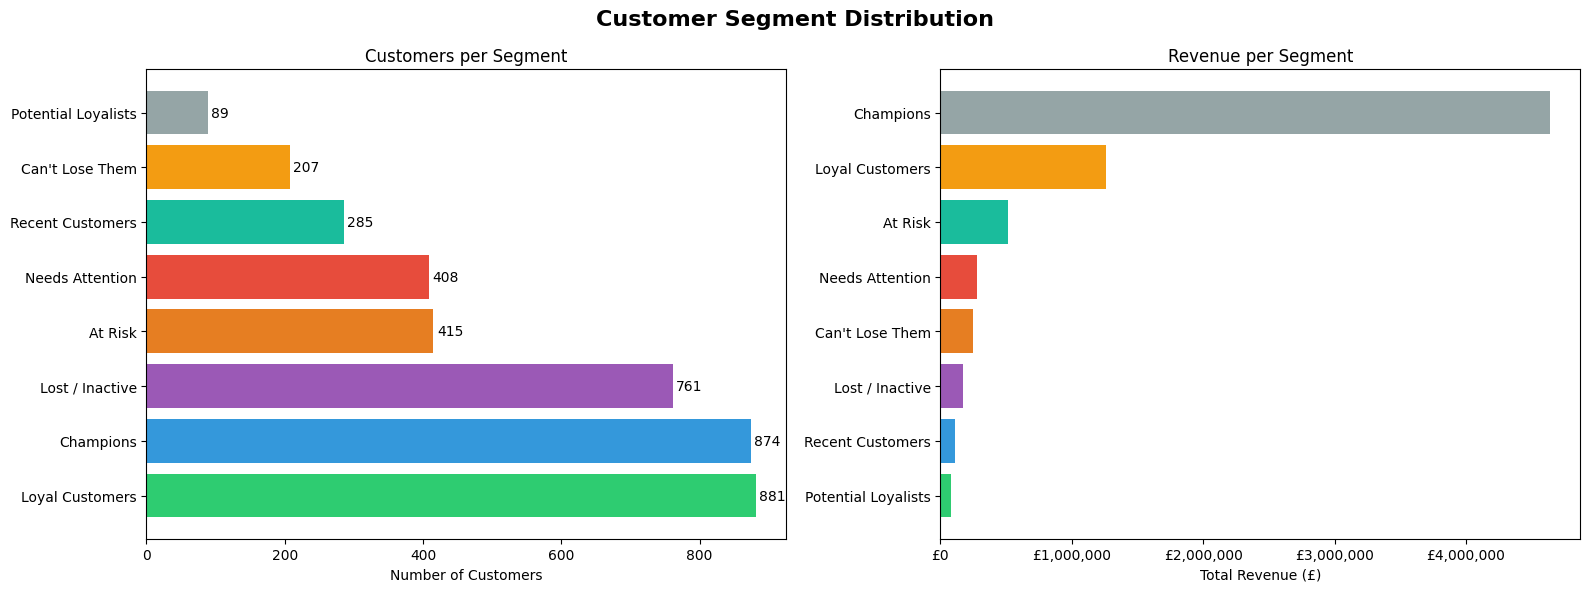

✅ Chart saved to images/


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Segment Distribution', fontsize=16, fontweight='bold')

# Count plot
seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#1abc9c','#f39c12','#95a5a6']

axes[0].barh(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customers per Segment')
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 5, i, str(v), va='center')

# Revenue plot
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
axes[1].barh(seg_revenue.index, seg_revenue.values, color=colors)
axes[1].set_xlabel('Total Revenue (£)')
axes[1].set_title('Revenue per Segment')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# save image
plt.tight_layout()
plt.savefig('C:\\Project\\customer-segmentation-rfm\\images\\segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/")